Data augmentation 
https://www.datacamp.com/tutorial/complete-guide-data-augmentation

In [3]:
%%capture
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

from keras import layers
import keras
from matplotlib.colors import ListedColormap
import pandas as pd
from sklearn.manifold import TSNE
from matplotlib import pyplot as plt

2024-03-20 15:49:36.447359: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-03-20 15:49:36.449354: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2024-03-20 15:49:36.477812: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-03-20 15:49:36.477843: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-03-20 15:49:36.478630: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to

In [4]:
dataset_path = 'Data/fake_microarray_data.csv'

In [5]:
training_data= pd.read_csv(dataset_path)
df = training_data

In [8]:
def map_to_category(age):
    if age < 35:
        return "Young"
    elif age > 65:
        return "Old"
    else:
        return "MiddleAge"


/tmp/ipykernel_1725733/4121538581.py:31: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_pca[i, 0], X_pca[i, 1], c=np.array([age / max(y_age), 0, 1 - age / max(y_age)]), marker=marker)
/tmp/ipykernel_1725733/4121538581.py:43: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_tsne[i, 0], X_tsne[i, 1], c=np.array([age / max(y_age), 0, 1 - age / max(y_age)]), marker=marker)


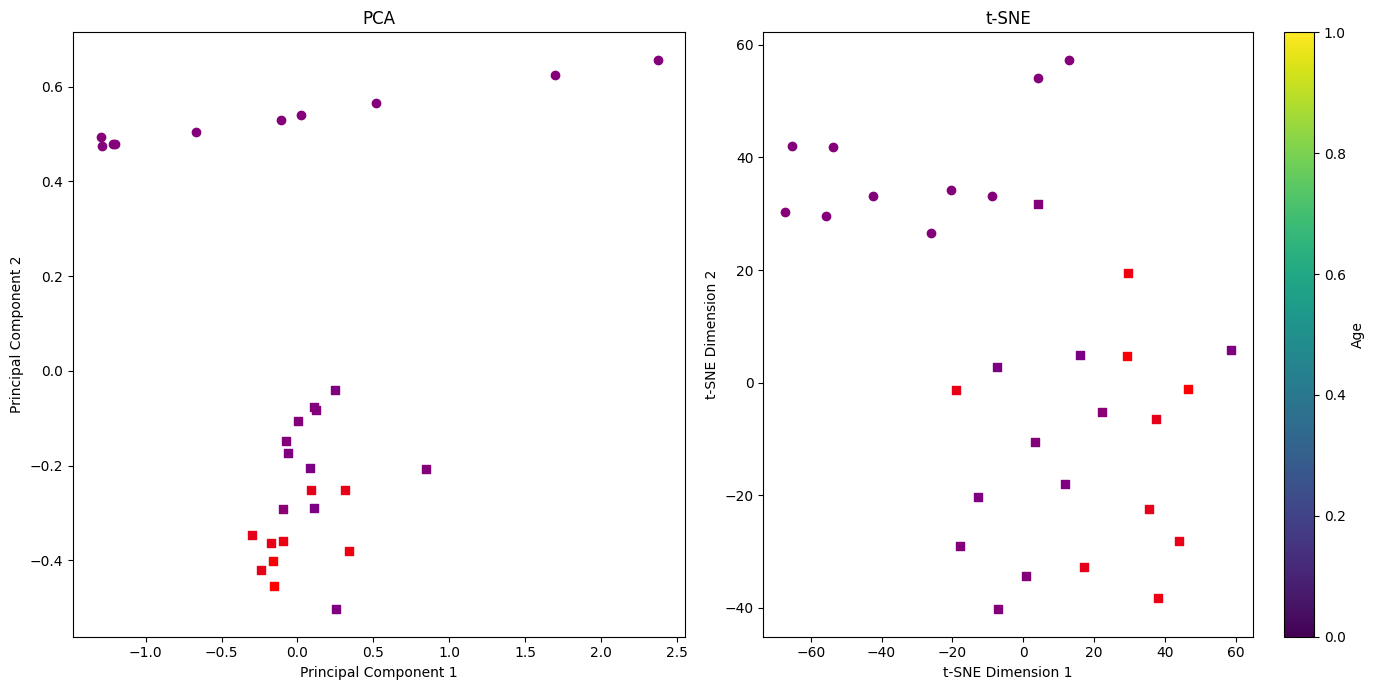

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Assuming your DataFrame is named df
# Perform dimensionality reduction
X = df.drop(columns=['Sample', 'Age', 'Class']).values  # Extracting only numeric columns
y_age = df['Age'].values
y_class = df['Class'].values

# Dimensionality reduction with PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Dimensionality reduction with t-SNE
tsne = TSNE(n_components=2, perplexity=10, random_state=30)
X_tsne = tsne.fit_transform(X)

# Plotting
plt.figure(figsize=(14, 7))

# Plotting PCA
plt.subplot(1, 2, 1)
for i, age in enumerate(y_age):
    if y_class[i] == 'Fake':
        marker = 'o'  # Circle for fake
    else:
        marker = 's'  # Square for real
    plt.scatter(X_pca[i, 0], X_pca[i, 1], c=np.array([age / max(y_age), 0, 1 - age / max(y_age)]), marker=marker)
plt.title('PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

# Plotting t-SNE
plt.subplot(1, 2, 2)
for i, age in enumerate(y_age):
    if y_class[i] == 'Fake':
        marker = 'o'  # Circle for fake
    else:
        marker = 's'  # Square for real
    plt.scatter(X_tsne[i, 0], X_tsne[i, 1], c=np.array([age / max(y_age), 0, 1 - age / max(y_age)]), marker=marker)
plt.title('t-SNE')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')

plt.colorbar(label='Age')
plt.tight_layout()
plt.show()
